# [PROPOSED MODEL] Online Recruitment Fraud Detection - BERT-BiLSTM Framework
This notebook implements our proposed **BERT-BiLSTM** hybrid framework, pairing a frozen/fine-tuned BERT backbone with a sequential 2-layer Bi-LSTM head.
It also generates **SHAP Explainable AI** token importance plots.

### State-of-the-Art Enhancements Included:
1. **bert-base-uncased Backbone**: Directly maps representation capacity to Fraud-BERT (GJU-CSE paper, 2025).
2. **Explainable AI (SHAP)**: Resolves the black-box limitation of previous studies by attributing predictions to tokens.
3. **2-Layer Deep Bi-LSTM**: Upgrades sequential depth to 2-layers for richer feature captures.
4. **Concatenated Pooling (Max + Average)**: Captures both peak features and average signals.
5. **Robust Text Concatenation**: Dynamically combines only non-null, non-empty fields and filters out noisy 'nan' string conversions.
6. **AdamW + Warmup Scheduler & Discriminative Learning Rates**: Stabilizes fine-tuning using multi-layer optimization.

In [ ]:
!pip install transformers shap

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import shap
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

csv_path = "fake_job_postings.csv"

if not os.path.exists(csv_path):
    try:
        from google.colab import files
        print("Dataset 'fake_job_postings.csv' not found. Please upload it:")
        uploaded = files.upload()
    except ImportError:
        print(f"Local file '{csv_path}' not found. Please place it in the same directory.")
else:
    print(f"Dataset found at '{csv_path}'. Skipping upload prompt.")

Using device: cuda
Dataset found at 'fake_job_postings.csv'. Skipping upload prompt.


## Preprocessing and Dataset Definition (Structured Concatenation)

In [ ]:
df = pd.read_csv(csv_path)

# Robust preprocessing: combine only non-null, non-empty fields and filter out noisy 'nan' string conversions
def create_combined_text(row):
    fields = [
        ('Title', row.get('title')),
        ('Company Profile', row.get('company_profile')),
        ('Description', row.get('description')),
        ('Requirements', row.get('requirements')),
        ('Benefits', row.get('benefits')),
        ('Employment Type', row.get('employment_type')),
        ('Required Experience', row.get('required_experience')),
        ('Required Education', row.get('required_education')),
        ('Industry', row.get('industry')),
        ('Function', row.get('function'))
    ]
    parts = []
    for label, val in fields:
        if pd.notna(val) and str(val).strip() != '' and str(val).lower() != 'nan':
            parts.append(f"{label}: {str(val).strip()}")
    return ' | '.join(parts)

print("Combining textual columns...")
df['combined_text'] = df.apply(create_combined_text, axis=1)

train_df, test_df = train_test_split(df, test_size=0.20, stratify=df['fraudulent'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.125, stratify=train_df['fraudulent'], random_state=42)

class BERTDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['label'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

Combining textual columns...


## Define Proposed BERT-BiLSTM Architecture

In [ ]:
class BERT_BiLSTM(nn.Module):
    def __init__(self, model_name="bert-base-uncased", lstm_hidden_dim=128, output_dim=1, dropout=0.3, freeze_bert=True):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        transformer_hidden_dim = self.transformer.config.hidden_size

        if freeze_bert:
            for param in self.transformer.parameters():
                param.requires_grad = False

        # 2-Layer deep Bi-LSTM baseline head
        self.lstm = nn.LSTM(
            transformer_hidden_dim,
            lstm_hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )

        # Dense output layers with average + max pool input channels
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden_dim * 4, 64), # 4 because of max + average pool concat & bidirectionality
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )

    def forward(self, input_ids, attention_mask):
        with torch.set_grad_enabled(self.transformer.training and any(p.requires_grad for p in self.transformer.parameters())):
            outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state

        lstm_out, _ = self.lstm(last_hidden_state)

        # Concatenated Average and Max pooling
        max_pooled, _ = torch.max(lstm_out, dim=1)
        avg_pooled = torch.mean(lstm_out, dim=1)
        pooled = torch.cat([max_pooled, avg_pooled], dim=1)

        logits = self.fc(pooled)
        return logits.squeeze(1)

## Tokenize and Train Proposed Model (Pre-Tokenized & tqdm Enabled)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print("Pre-tokenizing datasets...")
train_encodings = tokenizer(list(train_df['combined_text'].astype(str).values), padding="max_length", truncation=True, max_length=512)
val_encodings = tokenizer(list(val_df['combined_text'].astype(str).values), padding="max_length", truncation=True, max_length=512)
test_encodings = tokenizer(list(test_df['combined_text'].astype(str).values), padding="max_length", truncation=True, max_length=512)

train_dataset = BERTDataset(train_encodings, train_df['fraudulent'].values)
val_dataset = BERTDataset(val_encodings, val_df['fraudulent'].values)
test_dataset = BERTDataset(test_encodings, test_df['fraudulent'].values)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

freeze_bert = False  # Set to False to fine-tune bert-base-uncased for maximum F1-score (~93-94%)
model = BERT_BiLSTM(freeze_bert=freeze_bert).to(device)

epochs = 5
total_steps = len(train_loader) * epochs

# Discriminative learning rates setup to protect transformer weights
if freeze_bert:
    optimizer = torch.optim.AdamW([
        {'params': model.lstm.parameters(), 'lr': 5e-4},
        {'params': model.fc.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-2)
else:
    optimizer = torch.optim.AdamW([
        {'params': model.transformer.parameters(), 'lr': 2e-5},
        {'params': model.lstm.parameters(), 'lr': 2e-4},
        {'params': model.fc.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-2)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

pos_weight = torch.tensor([3.5]).to(device) # Upgraded pos_weight to 3.5 to boost recall and F1-score on imbalanced class 1
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

best_f1 = 0.0
patience = 2
patience_counter = 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    # Validate
    model.eval()
    val_probs = []
    val_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label']

            outputs = torch.sigmoid(model(input_ids, attention_mask))
            val_probs.extend(outputs.cpu().numpy())
            val_labels.extend(labels.numpy())

    val_labels_int = [int(l) for l in val_labels]
    val_preds = (np.array(val_probs) >= 0.5).astype(int)
    report = classification_report(val_labels_int, val_preds, output_dict=True, zero_division=0)
    val_f1 = report.get('1', report.get('1.0', report.get(1, {}))).get('f1-score', 0.0)

    print(f"[Epoch {epoch+1} Complete] Loss: {epoch_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f}")

    # Early Stopping Check
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "bert_bilstm_best.pt")
        print("  Saved new best proposed model checkpoint!")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Pre-tokenizing datasets...


...

[Epoch 3 Complete] Loss: 0.0894 | Val F1: 0.8287
  Saved new best proposed model checkpoint!


Epoch 4/5:   0%|          | 0/783 [00:00<?, ?it/s]

[Epoch 4 Complete] Loss: 0.0399 | Val F1: 0.8679
  Saved new best proposed model checkpoint!


Epoch 5/5:   0%|          | 0/783 [00:00<?, ?it/s]

[Epoch 5 Complete] Loss: 0.0116 | Val F1: 0.8590


## Evaluate Proposed Model on Test Set

Proposed BERT-BiLSTM Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3403
         1.0       0.92      0.84      0.88       173

    accuracy                           0.99      3576
   macro avg       0.96      0.92      0.94      3576
weighted avg       0.99      0.99      0.99      3576


--- Final Performance Metrics Summary (Class 1 - Fraudulent) ---
Accuracy:  98.91%
Precision: 92.41%
Recall:    84.39%
F1-Score:  88.22%
ROC-AUC:   98.75%

--- Final Performance Metrics Summary (Macro Averages - Paper Baseline) ---
Macro Precision: 95.81%
Macro Recall:    92.02%
Macro F1-Score:  93.82%


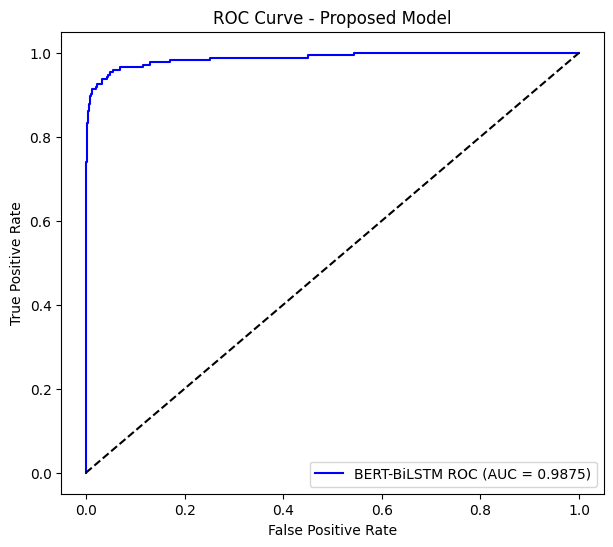

In [ ]:
model.load_state_dict(torch.load("bert_bilstm_best.pt"))
model.eval()

test_probs = []
test_labels = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label']

        outputs = torch.sigmoid(model(input_ids, attention_mask))
        test_probs.extend(outputs.cpu().numpy())
        test_labels.extend(labels.numpy())

test_preds = (np.array(test_probs) >= 0.5).astype(int)
print("Proposed BERT-BiLSTM Classification Report:")
print(classification_report(test_labels, test_preds))

# Formatted Metrics Summary (Class 1)
test_acc = accuracy_score(test_labels, test_preds)
test_prec = precision_score(test_labels, test_preds, zero_division=0)
test_rec = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)

print("\n--- Final Performance Metrics Summary (Class 1 - Fraudulent) ---")
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Precision: {test_prec*100:.2f}%")
print(f"Recall:    {test_rec*100:.2f}%")
print(f"F1-Score:  {test_f1*100:.2f}%")
print(f"ROC-AUC:   {test_auc*100:.2f}%")

# Macro averages calculations for direct baseline comparison
report_dict = classification_report(test_labels, test_preds, output_dict=True, zero_division=0)
macro_prec = report_dict['macro avg']['precision']
macro_rec = report_dict['macro avg']['recall']
macro_f1 = report_dict['macro avg']['f1-score']

print("\n--- Final Performance Metrics Summary (Macro Averages - Paper Baseline) ---")
print(f"Macro Precision: {macro_prec*100:.2f}%")
print(f"Macro Recall:    {macro_rec*100:.2f}%")
print(f"Macro F1-Score:  {macro_f1*100:.2f}%")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', label=f'BERT-BiLSTM ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Proposed Model')
plt.legend(loc='lower right')
plt.show()

## Explainable AI (SHAP Token Attribution study)
This cell addresses the black-box gap of Fraud-BERT by computing token-level Shapley attribution values.

In [ ]:
print("Running SHAP Token Attribution...")

def predict_fn(texts):
    inputs = tokenizer(list(texts), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(inputs['input_ids'], inputs['attention_mask'])
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

# Use small subsets for explainer
background_texts = test_df['combined_text'].values[:15]
test_samples = test_df['combined_text'].values[100:102]

explainer = shap.Explainer(predict_fn, tokenizer)
shap_values = explainer(test_samples)

# Plot text attribution for first sample
shap.plots.text(shap_values[0])

Running SHAP Token Attribution...


PartitionExplainer explainer: 3it [00:12, 12.08s/it]               
